In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Dataset

Run the cell given below to generate the data-matrix $\mathbf{X}$, which is of shape $(n, d)$, where $n$ denotes the number of samples and $d$ denotes the number of features. Ignore the vector $y$. You will be using this dataset for the rest of the assignment. Do not edit this cell.

In [2]:
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=1000, factor=0.9, noise=0.2, random_state=0)

## Problem 1
Plot the dataset using matplotlib.

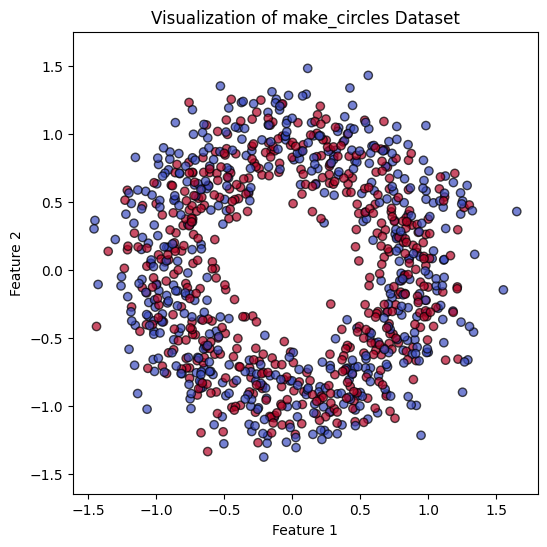

In [3]:
# Create the plot
plt.figure(figsize=(6, 6))

# Scatter plot
plt.scatter(X[:, 0], X[:, 1], 
            c=y,                # Color by class label
            cmap='coolwarm',    # Colormap for class separation
            edgecolors='k',     # Black edge around points
            alpha=0.7)

plt.title("Visualization of make_circles Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.axis('equal')  # Preserve geometric proportions
plt.show()

## Problem 2
How many samples are there in the dataset?


In [4]:
n_samples = X.shape[0]
print("Number of samples:", n_samples)

Number of samples: 1000


## Problem 3
How many features are there in the dataset?

In [5]:
# Enter your solution here
n_features = X.shape[1]
print("Number of features:", n_features)

Number of features: 2


## Problem 4
Find the kernel matrix $K$ using the polynomial kernel with degree $2$.

<u>Conversion</u>

Enter the following quantity as your answer correct to two decimal places:

$$
\cfrac{1}{n} \sqrt{\sum \limits_{i = 1}^{n} \sum \limits_{j = 1}^{n} (K_{ij})^2}
$$

In [7]:
# Enter your solution here
# Compute polynomial kernel (degree 2)
K = (X @ X.T + 1) ** 2

# Number of samples
n = X.shape[0]

# Compute required quantity
result = (1/n) * np.sqrt(np.sum(K**2))

print(round(result, 2))

2.1


## Problem 5
Find the kernel matrix $K$ using the Gaussian kernel with parameter $\sigma = 2$.

<u>Conversion</u>

Enter the following quantity as your answer correct to two decimal places:

$$
\cfrac{1}{n} \sqrt{\sum \limits_{i = 1}^{n} \sum \limits_{j = 1}^{n} (K_{ij})^2}
$$

In [8]:

n = X.shape[0]
sigma = 2

# Compute squared norms
sq_norms = np.sum(X**2, axis=1)

# Compute squared distance matrix
sq_dists = sq_norms[:, None] + sq_norms[None, :] - 2 * (X @ X.T)

# Compute Gaussian kernel matrix
K = np.exp(-sq_dists / (2 * sigma**2))

# Compute required quantity
result = (1/n) * np.sqrt(np.sum(K**2))

print(round(result, 2))

0.81


## Problem 6
Find the center of the kernel matrix $K$ obtained in problem 2. Call this centered matrix $KC$.

<u>Conversion</u>

Enter the following quantity as your answer correct to two decimal places:

$$
\cfrac{1}{n} \sqrt{\sum \limits_{i = 1}^{n} \sum \limits_{j = 1}^{n} KC_{ij}^2}
$$

In [10]:
# Enter your solution here
K = (X @ X.T + 1) ** 2

n = K.shape[0]

# Compute row means
row_mean = np.mean(K, axis=1, keepdims=True)

# Compute total mean
total_mean = np.mean(K)

# Center the kernel matrix
KC = K - row_mean - row_mean.T + total_mean

# Compute required quantity
result = (1/n) * np.sqrt(np.sum(KC**2))

print(round(result, 2))

1.45
